# Pressing Activity vs Pressing Effectiveness - Barcelona La Liga 2020/21

### Purpose
This analysis investigates whether pressing activity and pressing effectiveness tell the same story for Barcelona under Ronald Koeman. Using StatsBomb open event data, pressing locations, volumes, and efficiency are analyzed across 35 matches to understand how Barcelona's pressing behavior related to match outcomes - and if usual pressing metrics remain relevant for a possesion based team. 

### Dataset
StatsBomb Open Data - La Liga 2020/2021
competition_id = 11 , season_id = 90
35 matches, 139,000+ events including passes, pressures, duels, shots, and more - each with coordinates

### Approach
1. Load and Explore StatsBomb event data
2. Analyze pressing volume by match result
3. Visualize pressing locations using pitch heatmaps
4. Compare pressing behavior related to results and oppoent
5. Calculate Pressing Effectiveness
6. Evaluate what pressing activity vs pressing effectiveness revealed about Koeman's Barcelona in the 20/21 season.

In [1]:
from statsbombpy import sb
import pandas as pd


In [2]:
# Analysis on 20/21 La Liga season
# Pull match data for 20/21 La Liga season
matches = sb.matches(competition_id=11, season_id=90)
print(matches.head())
print(matches.shape)
print(matches.columns.tolist())

   match_id  match_date      kick_off      competition     season  \
0   3773386  2020-10-31  21:00:00.000  Spain - La Liga  2020/2021   
1   3773565  2021-01-09  18:30:00.000  Spain - La Liga  2020/2021   
2   3773457  2021-05-16  18:30:00.000  Spain - La Liga  2020/2021   
3   3773631  2021-02-07  21:00:00.000  Spain - La Liga  2020/2021   
4   3773665  2021-03-06  21:00:00.000  Spain - La Liga  2020/2021   

          home_team   away_team  home_score  away_score match_status  ...  \
0  Deportivo Alavés   Barcelona           1           1    available  ...   
1           Granada   Barcelona           0           4    available  ...   
2         Barcelona  Celta Vigo           1           2    available  ...   
3        Real Betis   Barcelona           2           3    available  ...   
4           Osasuna   Barcelona           0           2    available  ...   

             last_updated_360 match_week competition_stage  \
0  2023-07-25T04:25:41.348202          8    Regular Season  

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [3]:
# Pull events for all 35 matches one at a time and combine
all_events = []

for match_id in matches['match_id']:
    match_events = sb.events(match_id=match_id)
    all_events.append(match_events)

all_events = pd.concat(all_events, ignore_index=True)

print(all_events.shape)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Pytho

(139030, 111)


## Pressing Events

Pressure events are filtered from the full event dataset. Each row represents 
a single press attempt by a player, including the x/y location on the pitch 
where the press occurred. 

StatsBomb coordinates run from 0 to 120 on the x-axis 
(left to right, always attacking direction) and 0 to 80 on the y-axis. 
This allows us to map exactly where on the pitch each press happened.

In [4]:
# Filtering Data to the columns of interest
# Creates a copy of the dataframe; totally independent of original.
pressing = all_events[all_events['type'] == 'Pressure'].copy()

pressing['x'] = pressing['location'].apply(lambda loc: loc[0])
pressing['y'] = pressing['location'].apply(lambda loc: loc[1]) 

print(pressing.shape)
print(pressing[['team','player','x','y','minute']].head())
print(pressing['team'].value_counts())

(10832, 113)
                  team                          player     x     y  minute
3071  Deportivo Alavés     Deyverson Brum Silva Acosta  77.6  48.8       0
3072  Deportivo Alavés     Edgar Antonio Méndez Ortega  77.0  67.5       0
3073  Deportivo Alavés       Luis Jesús Rioja González  83.0  20.8       0
3074  Deportivo Alavés     Deyverson Brum Silva Acosta  91.5  24.0       0
3075  Deportivo Alavés  José Ignacio Peleteiro Ramallo  71.0  22.2       0
team
Barcelona           4629
Huesca               460
Getafe               422
Deportivo Alavés     422
Celta Vigo           420
Real Madrid          416
Real Sociedad        413
Sevilla              377
Granada              364
Real Valladolid      362
Atlético Madrid      359
Osasuna              340
Levante UD           339
Real Betis           317
Athletic Club        283
Valencia             252
Cádiz                243
Villarreal           237
Elche                177
Name: count, dtype: int64


In [5]:
barca_press = pressing[pressing['team'] == 'Barcelona'].copy()

# how many presses per match?
barca_press_per_match = barca_press.groupby('match_id').size().reset_index(name='press_count')

print(barca_press_per_match.describe())
print(f"\nAverage presses per match: {barca_press_per_match['press_count'].mean():.1f}")

           match_id  press_count
count  3.500000e+01    35.000000
mean   3.773023e+06   132.257143
std    2.118780e+03    41.520613
min    3.764440e+06    72.000000
25%    3.773422e+06    94.000000
50%    3.773547e+06   130.000000
75%    3.773611e+06   159.000000
max    3.773695e+06   237.000000

Average presses per match: 132.3


In [6]:
# Match Results for Barcelona
barca_matches = matches[(matches['home_team'] == 'Barcelona') | (matches['away_team'] == 'Barcelona')].copy()

# Result column: Win, Loss, Draw from Barcelona's perspective
def get_result(row):
    if row['home_team'] == 'Barcelona':
        if row['home_score'] > row['away_score']:
            return 'Win'
        elif row['home_score'] < row['away_score']:
            return 'Loss'
        else:
            return 'Draw'
    else:  # Barcelona is away team
        if row['away_score'] > row['home_score']:
            return 'Win'
        elif row['away_score'] < row['home_score']:
            return 'Loss'
        else:
            return 'Draw'
barca_matches['result'] = barca_matches.apply(get_result, axis=1)

# Merge the results back to the pressing data
barca_analysis = barca_press.merge(barca_matches[['match_id', 'result','home_team', 
                                                  'away_team','home_score', 'away_score','match_week']]
                                   , on='match_id', how='left')
print(barca_analysis['result'].value_counts())
print(barca_analysis.head())

result
Win     2989
Loss     881
Draw     759
Name: count, dtype: int64
  50_50 bad_behaviour_card ball_receipt_outcome ball_recovery_offensive  \
0   NaN                NaN                  NaN                     NaN   
1   NaN                NaN                  NaN                     NaN   
2   NaN                NaN                  NaN                     NaN   
3   NaN                NaN                  NaN                     NaN   
4   NaN                NaN                  NaN                     NaN   

  ball_recovery_recovery_failure carry_end_location clearance_aerial_won  \
0                            NaN                NaN                  NaN   
1                            NaN                NaN                  NaN   
2                            NaN                NaN                  NaN   
3                            NaN                NaN                  NaN   
4                            NaN                NaN                  NaN   

  clearance_body_par

In [7]:
# Recalculate press counts per match cleanly
barca_press_per_match = barca_press.groupby('match_id').size().reset_index(name='press_count')

# Merge with match results
barca_analysis = barca_press_per_match.merge(
    barca_matches[['match_id', 'result', 'home_team', 'away_team',
                   'home_score', 'away_score', 'match_week']],
    on='match_id'
)

print(barca_analysis.columns.tolist())
print(barca_analysis.shape)
print(barca_analysis.head())

['match_id', 'press_count', 'result', 'home_team', 'away_team', 'home_score', 'away_score', 'match_week']
(35, 8)
   match_id  press_count result      home_team        away_team  home_score  \
0   3764440          135    Win      Barcelona            Elche           3   
1   3764661          140    Win  Athletic Club        Barcelona           2   
2   3773369          187    Win      Barcelona           Huesca           4   
3   3773372          177   Draw      Barcelona  Atlético Madrid           0   
4   3773377          109   Draw      Barcelona         Valencia           2   

   away_score  match_week  
0           0           1  
1           3           2  
2           1          27  
3           0          35  
4           2          14  


### Pressing Volume by Result
The bar plot shows Barcelona's pressing volume average per match across results. 
Pressing volume did not vary dramatically across results. Wins show a slightly higher average press count per match but the difference is marginal.

The plot suggests that pressing volume matters less than where and how effectively they pressed.

result
Win     135.863636
Draw    126.500000
Loss    125.857143
Name: press_count, dtype: float64


/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_47846/1076997219.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=press_by_result.index, y=press_by_result.values,


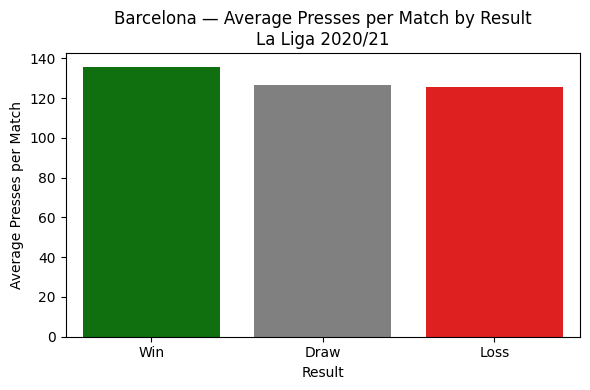

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Average presses per match by result
press_by_result = barca_analysis.groupby('result')['press_count'].mean().sort_values(ascending=False)
print(press_by_result)

# Visualization
plt.figure(figsize=(6,4))
sns.barplot(x=press_by_result.index, y=press_by_result.values,
            order=['Win', 'Draw', 'Loss'],
            palette={'Win':'green', 'Draw':'gray', 'Loss':'red'})
plt.title('Barcelona — Average Presses per Match by Result\nLa Liga 2020/21')
plt.xlabel('Result')
plt.ylabel('Average Presses per Match')
plt.tight_layout()
plt.show()

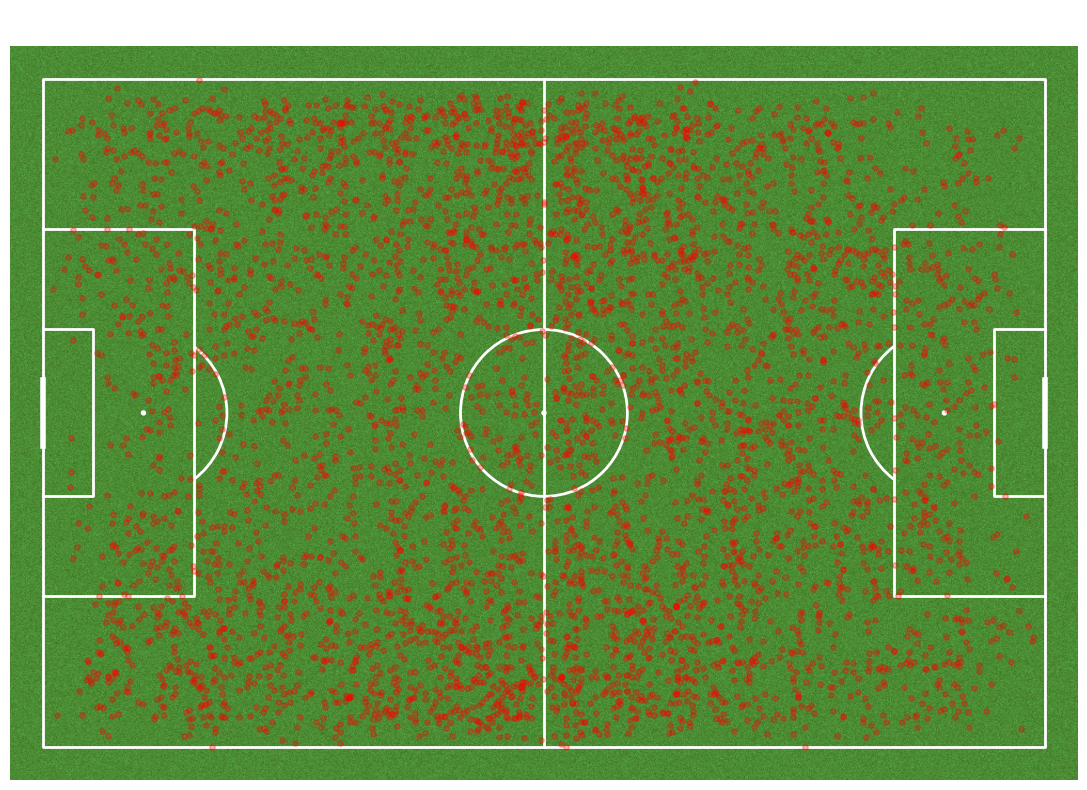

In [9]:
from mplsoccer import Pitch

# Draw a pitch and plot Barcelona's pressing locations
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot every press attempt as a dot
ax.scatter(barca_press['x'], barca_press['y'], 
           alpha=0.3, s=15, color='red', zorder=3)

ax.set_title("Barcelona Pressing Locations — La Liga 2020/21", 
             fontsize=14, color='white', pad=15)

plt.tight_layout()
plt.show()

### Pressing Location — Heatmap
A heatmap of all Barcelona pressing events across the season reveals that Koeman's Barcelona tended to press more heavily on the wings also with a slight bias toward the left side of the pitch. This reflects the adaptive formations Koeman deployed — whether in a 4-2-3-1 or a three with wingbacks pushing high. Pressing in the opponent's final third was minimal, indicating this was not a high press system but rather a mid block with wing-oriented press triggers.

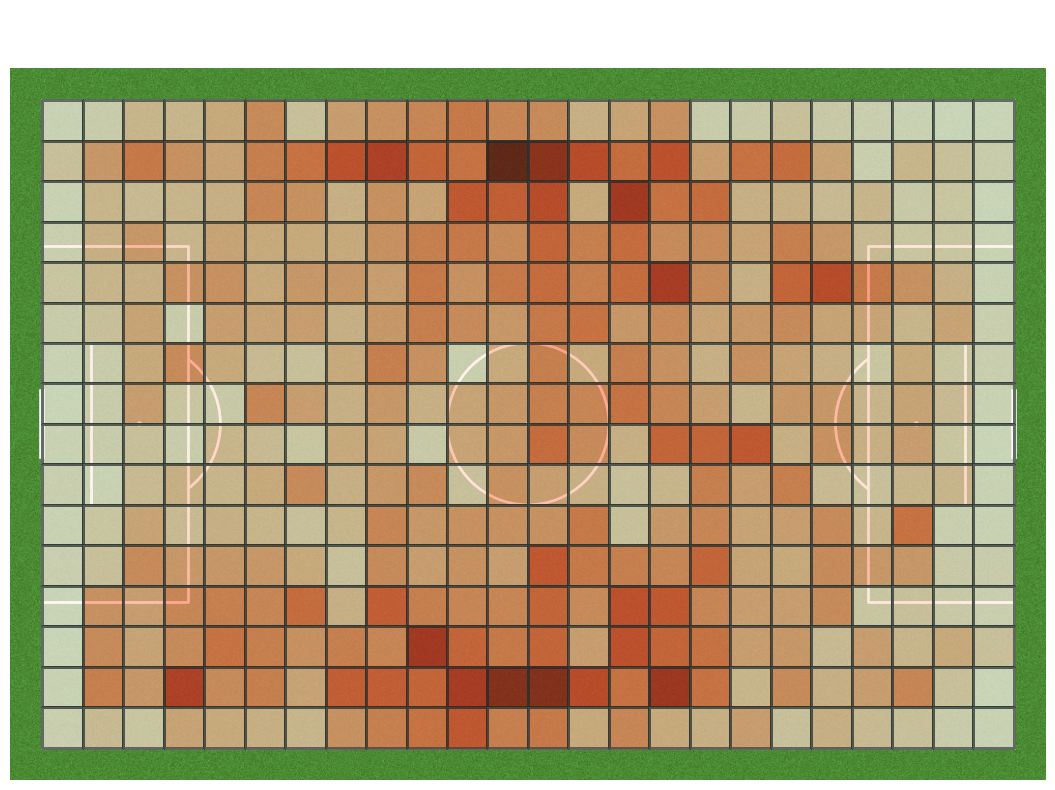

In [10]:
# Heatmap is far more readable than individual dots for this volume of data
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# Create a heatmap of pressing locations
bin_statistic = pitch.bin_statistic(barca_press['x'], barca_press['y'], 
                                     statistic='count', bins=(24, 16))
pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolors='#22312b', alpha = 0.7)

ax.set_title("Barcelona Pressing Intensity Heatmap — La Liga 2020/21\nDarker = More Presses", 
             fontsize=14, color='white', pad=15)

plt.tight_layout()
plt.show()

### Pressing Location by Result
The three heatmaps tell a clear story:

**Wins** — Pressing is more spread out across the pitch with more consistent coverage and slightly more advanced positioning into the opponent's half. The heatmap conveys that the press was more organized and purposeful.

**Draws** — Pressing shows a mid-block pattern, concentrated in the middle third and on the wings, with less penetration into the opponent's half. This could convey that Barcelona were playing an oppoenent who absorbed pressure well, forcing a more conversative press and a focus on cutting off passing lanes, and pressing in specific zones rather than aggresive behavior.

**Losses** — Overall pressing activity drops with less coverage across the pitch. Some press actions appear in and around the opponent's box, indicating Barcelona were chasing the game. Additionally, the lack of pressing coverage across the core center of the pitch conveys pressing desperately rather than in an organized structure.

The three heatmaps collectively suggest that in wins, Barcelona's press was more organized and positionally advanced, while draws suggest a conservative and reactive approach, and losses show a desperate and unstructured press.


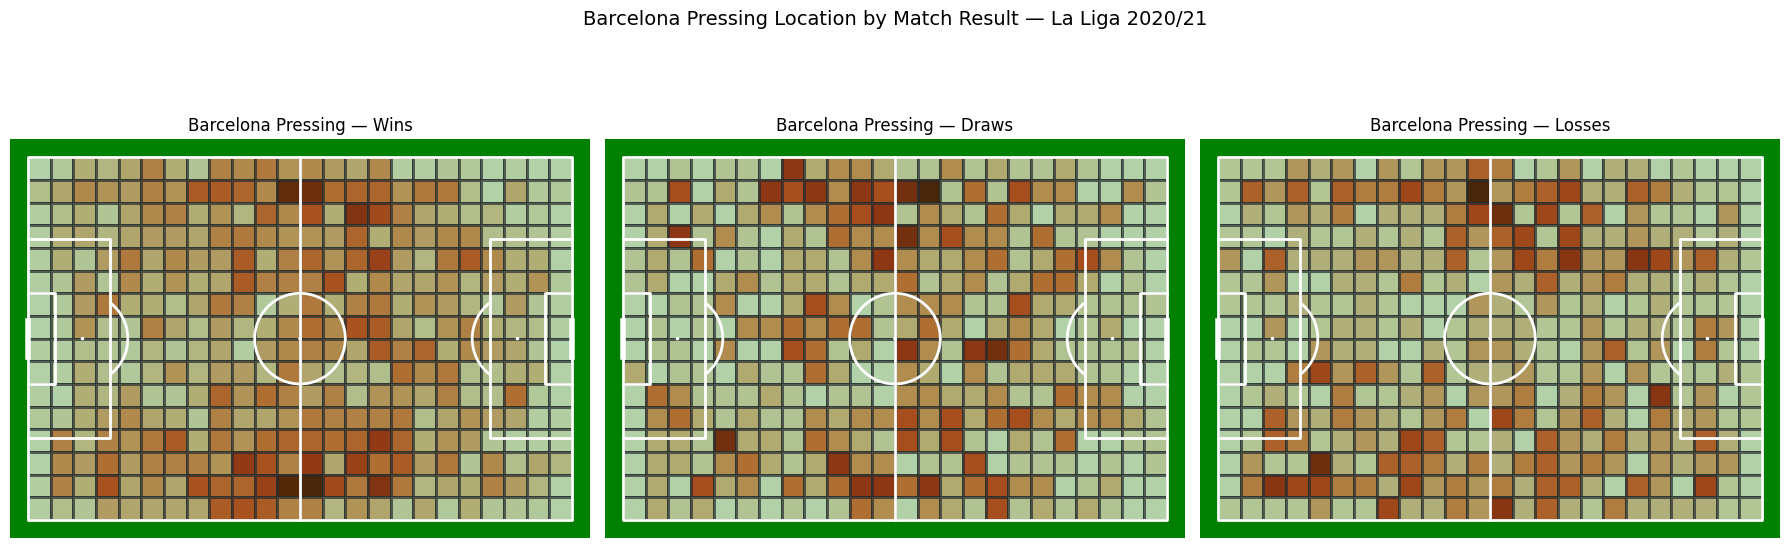

In [11]:
# Split pressing locations by result
barca_press_result = barca_press.merge(
    barca_analysis[['match_id', 'result']], on='match_id'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
results = ['Win', 'Draw', 'Loss']
titles = ['Barcelona Pressing — Wins', 'Barcelona Pressing — Draws', 'Barcelona Pressing — Losses']

for ax, result, title in zip(axes, results, titles):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='green', 
                  line_color='white', line_zorder=2)
    pitch.draw(ax=ax)
    
    subset = barca_press_result[barca_press_result['result'] == result]
    bin_statistic = pitch.bin_statistic(subset['x'], subset['y'],
                                         statistic='count', bins=(24, 16))
    pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', 
                  edgecolors='#22312b', alpha=0.7)
    ax.set_title(title, color='black', fontsize=12)

plt.suptitle("Barcelona Pressing Location by Match Result — La Liga 2020/21", 
             fontsize=14, color='black', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Which gameweeks were the Atletico matches?
atleti_matches = matches[(matches['home_team'] == 'Atletico Madrid') | 
                          (matches['away_team'] == 'Atletico Madrid')]
print(atleti_matches[['match_week', 'home_team', 'away_team', 'home_score', 'away_score','match_id']])

Empty DataFrame
Columns: [match_week, home_team, away_team, home_score, away_score, match_id]
Index: []


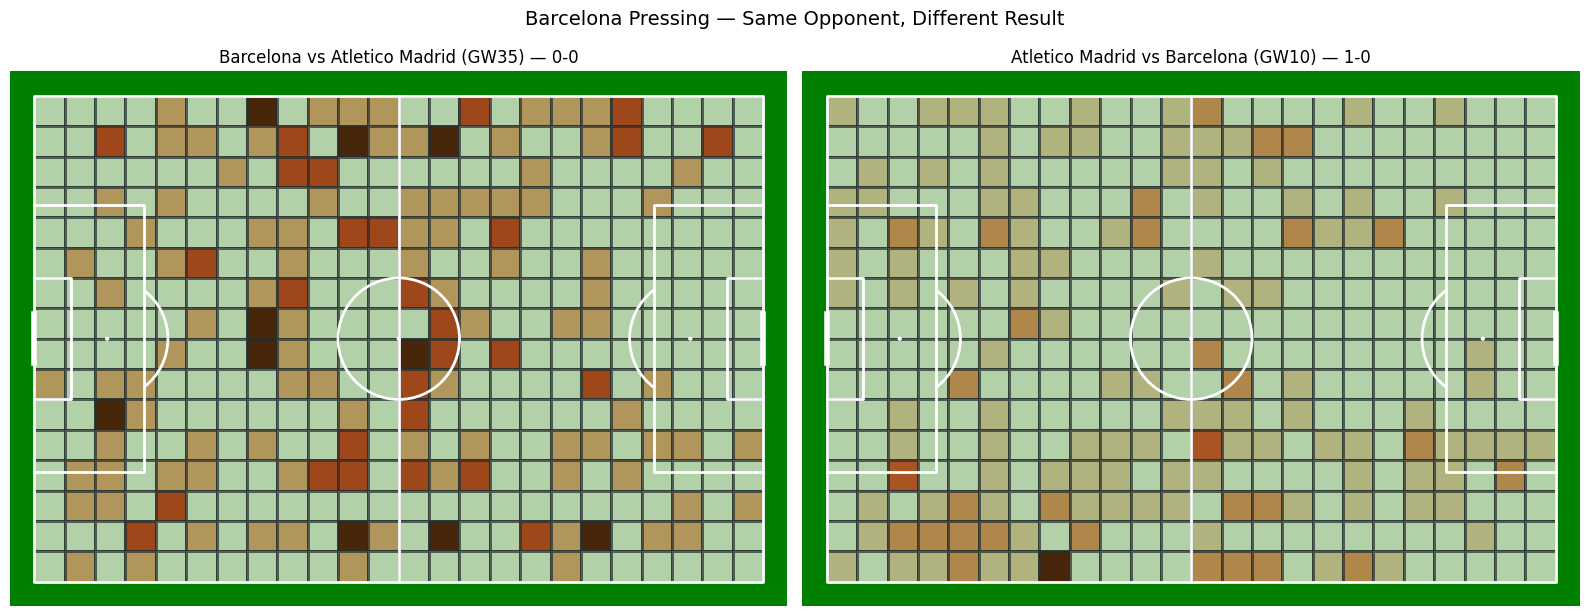

In [13]:
# Compare pressing heatmaps - Atletico draw vs Atletico loss
# Same opponent, different result

atleti_draw_press = barca_press_result[
    (barca_press_result['match_id'] == 3773372) & 
    (barca_press_result['team'] == 'Barcelona')
]

atleti_loss_press = barca_press_result[
    (barca_press_result['match_id'] == 3773656) & 
    (barca_press_result['team'] == 'Barcelona')
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

matches_to_plot = [
    (atleti_draw_press, 'Barcelona vs Atletico Madrid (GW35) — 0-0'),
    (atleti_loss_press, 'Atletico Madrid vs Barcelona (GW10) — 1-0')
]

for ax, (subset, title) in zip(axes, matches_to_plot):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='green',
                  line_color='white', line_zorder=2)
    pitch.draw(ax=ax)
    
    bin_statistic = pitch.bin_statistic(subset['x'], subset['y'],
                                         statistic='count', bins=(24, 16))
    pitch.heatmap(bin_statistic, ax=ax, cmap='Reds',
                  edgecolors='#22312b', alpha=0.7)
    ax.set_title(title, color='black', fontsize=12)

plt.suptitle("Barcelona Pressing — Same Opponent, Different Result",
             fontsize=14, color='black', y=1.02)
plt.tight_layout()
plt.show()

### Same Opponents, Different Result - Atletico Madrid Press Evaluation

To further visualize and understand the pattern shifts based on result and opponent context, Barcelona's two matches against Atletico Madrid were compared: a 0-0 draw at home and a 1-0 loss away.

The draw heatmap displays a more structured and conservative pressing behavior with activity being mostly across the wing and central areas of the pitch, avoiding over-commitment. 

The loss heatmap displays minimal pressing across the center pitch, with its triggers falling mostly on the wing, consistent with the loss pattern discovered earlier. 

While only two matches, keeping the opponent constant, support the identified pattern visible across the season, where a more structured and centrally imposed pressing behavior is seen in better results, as opposed to relying on wing-dependent pressing triggers seen in losses. 

**Note**, gameweek context plays a part in the dynamic of the game itself, where a team looking for a particular result could adapt its tactics and shape how the game is played for both teams, having the potential to impact a team's pressing behavior.



In [14]:
# Pull all events and add match result info
all_events_result = all_events.merge(
    barca_analysis[['match_id', 'result']], on='match_id', how='left'
)

# For each match identify who Barcelona's opponent was
all_events_result = all_events_result.merge(
    barca_matches[['match_id', 'home_team', 'away_team']], on='match_id', how='left'
)

# Identify opponent team for each event
all_events_result['opponent'] = all_events_result.apply(
    lambda row: row['away_team'] if row['team'] == 'Barcelona' else row['home_team'], 
    axis=1
)

# Extract coordinates
all_events_result['x'] = all_events_result['location'].apply(
    lambda loc: loc[0] if isinstance(loc, list) else None
)
all_events_result['y'] = all_events_result['location'].apply(
    lambda loc: loc[1] if isinstance(loc, list) else None
)

print(all_events_result.shape)
print(all_events_result['team'].value_counts().head(5))

(139030, 117)
team
Barcelona          86274
Sevilla             3883
Villarreal          3632
Atlético Madrid     3598
Real Madrid         3531
Name: count, dtype: int64


In [15]:
# Press Success Rate
# When Barcelona pressed, how often did it lead to a positive outcome

barca_pressures = all_events_result[(all_events_result['team'] == 'Barcelona') & (all_events_result['type'] == 'Pressure')].copy()

# What occurs after the press
all_events_sorted = all_events_result.sort_values(['match_id', 'possession', 'index']).reset_index(drop=True)

# Takes in the event that occurs after a press
press_outcomes = []

# Loop through each single press event and find what happens next
for outcomes, press in barca_pressures.iterrows():
    same_possession = all_events_sorted[
        (all_events_sorted['match_id'] == press['match_id']) &
        (all_events_sorted['possession'] == press['possession']) &
        (all_events_sorted['index'] > press['index'])
    ]

    if len(same_possession) > 0:
        next_event = same_possession.iloc[0]
        # Was the ball recovered by Barcelona or did the opponent maintain possession? 
        ball_rec = next_event['team'] == 'Barcelona'
    else:
        ball_rec = False

    press_outcomes.append({
        'match_id': press['match_id'],
        'press_index': press['index'],
        'ball_recovered': ball_rec,
        'counterpress': press['counterpress']
    })
press_outcomes_df = pd.DataFrame(press_outcomes)

press_outcomes_df = press_outcomes_df.merge(barca_analysis[['match_id', 'result']], on='match_id')

print(press_outcomes_df.head(10))


# Fill NaN in counterpress with False
# StatsBomb only marks True when it is a counterpress, leaves blank otherwise
press_outcomes_df['counterpress'] = press_outcomes_df['counterpress'].fillna(False)

print(f"Overall Press Success Rate: {press_outcomes_df['ball_recovered'].mean():.2%}")
print(f"Counterpress Success Rate: {press_outcomes_df[press_outcomes_df['counterpress'] == True]['ball_recovered'].mean():.2%}")
print(f"Regular Press Success Rate: {press_outcomes_df[press_outcomes_df['counterpress'] == False]['ball_recovered'].mean():.2%}")
print(f"\nCounterpress count: {press_outcomes_df['counterpress'].sum()}")
print(f"Regular press count: {(press_outcomes_df['counterpress'] == False).sum()}")

   match_id  press_index  ball_recovered counterpress result
0   3773386           55           False         True   Draw
1   3773386          124           False          NaN   Draw
2   3773386          166            True          NaN   Draw
3   3773386          175           False          NaN   Draw
4   3773386          181           False          NaN   Draw
5   3773386          307           False         True   Draw
6   3773386          312           False         True   Draw
7   3773386          314           False          NaN   Draw
8   3773386          340           False         True   Draw
9   3773386          370           False          NaN   Draw
Overall Press Success Rate: 15.12%
Counterpress Success Rate: 16.80%
Regular Press Success Rate: 14.57%

Counterpress count: 1149
Regular press count: 3480


/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_47846/2241589224.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  press_outcomes_df['counterpress'] = press_outcomes_df['counterpress'].fillna(False)


In [16]:
# Press success rate by match result
press_by_result = press_outcomes_df.groupby('result')['ball_recovered'].mean()
counterpress_by_result = press_outcomes_df[press_outcomes_df['counterpress'] == True].groupby('result')['ball_recovered'].mean()

print("Overall press success by result:")
print(press_by_result)
print("\nCounterpress success by result:")
print(counterpress_by_result)

Overall press success by result:
result
Draw    0.144928
Loss    0.158910
Win     0.150552
Name: ball_recovered, dtype: float64

Counterpress success by result:
result
Draw    0.193237
Loss    0.142202
Win     0.168508
Name: ball_recovered, dtype: float64


/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_47846/3192591210.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=press_by_result.index, y=press_by_result.values,
/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_47846/3192591210.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counterpress_by_result.index, y=counterpress_by_result.values,


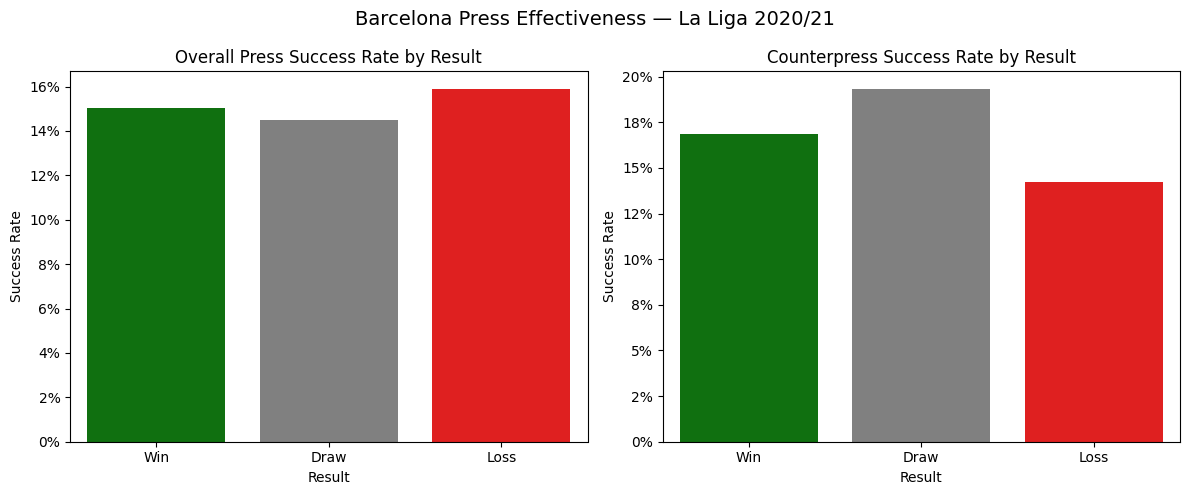

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall press success by result
sns.barplot(x=press_by_result.index, y=press_by_result.values,
            order=['Win', 'Draw', 'Loss'],
            palette={'Win':'green', 'Draw':'gray', 'Loss':'red'},
            ax=axes[0])
axes[0].set_title('Overall Press Success Rate by Result')
axes[0].set_ylabel('Success Rate')
axes[0].set_xlabel('Result')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Counterpress success by result
sns.barplot(x=counterpress_by_result.index, y=counterpress_by_result.values,
            order=['Win', 'Draw', 'Loss'],
            palette={'Win':'green', 'Draw':'gray', 'Loss':'red'},
            ax=axes[1])
axes[1].set_title('Counterpress Success Rate by Result')
axes[1].set_ylabel('Success Rate')
axes[1].set_xlabel('Result')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Barcelona Press Effectiveness — La Liga 2020/21', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusion — Pressing Activity vs Pressing Effectiveness

This analysis set out to examine whether pressing activity and pressing effectiveness tell the same story for Barcelona under Koeman in La Liga 2020/21.

### Pressing Activity
The heatmaps revealed a clear pattern across results. In wins, Barcelona's pressing was more organized and positionally advanced, with triggers covering the wings and finding slightly more presence into the opponent's third. In draws, pressing became more concentrated in the middle third while maintaining wing triggers, potentially influenced by opponents who absorbed pressure well and forced a more conservative approach. In losses, overall pressing activity dropped with less coverage across the core center of the pitch — some pressing actions appearing around the opponent's box suggesting Barcelona were chasing the game and pressing desperately rather than in an organized structure.

If match context had no influence on pressing behavior, it could be suggested that Barcelona would have benefited from maintaining press coverage further into the opponent's third and focusing on the core center of the pitch rather than relying on wing triggered pressing alone.

### Pressing Effectiveness
Press success rate and counterpress success rate showed minimal variation across wins, draws and losses — hovering around 15% regardless of result. The counterpress showed a slight pattern where losses had the lowest success rate at 14.2%, suggesting that in games Barcelona ultimately lost, even their most urgent reactive pressing failed to consistently win the ball back. However the differences are small and not conclusive enough to draw a strong relation.

### Overall Conclusion
Barcelona's issue under Koeman was neither pressing volume nor pressing effectiveness in isolation — both remained relatively consistent across results. 
What differed was pressing organization and location. In wins the press was more structured, advanced and centrally coordinated. In draws and losses it became wing dependent, reactive and disorganized.

This points to a collective tactical issue rather than individual effort. 
As the heatmaps showed, Barcelona were not pressing as a unit with clear triggers and zones, they were pressing as individuals reacting to the ball.
The success rates confirmed it was not about pressing harder, it was about pressing collectively.

For Koeman's Barcelona, pressing location and organization mattered more than pressing volume or effectiveness — suggesting the problem was tactical structure rather than individual pressing effort. 
A finding that ultimately aligns with the season's result — Atletico Madrid winning La Liga by doing less, but doing 
it with far more tactical clarity.